In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import string
from os import listdir
from os.path import isfile, join
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import PowerNorm

In [2]:
sns.set_palette("colorblind")

## Rank evaluation

In [3]:
#Mean absolute rank error
def rank_evaluation(Rank_list, n_boot):
    df_combined = pd.concat(Rank_list, axis=0, ignore_index=True)
    
    real_model_rank_diff = abs(df_combined["Real Rank"] - df_combined['Model Rank'])
    model_errors = np.empty(n_boot)

    for i in range(n_boot):
        shuffled = real_model_rank_diff.sample(frac=1, replace=True)
        model_errors[i] = np.mean(shuffled)  # sum()/len() equivalent

    # Null distribution summary
    model_mean = model_errors.mean()
    model_std  = model_errors.std(ddof=1)
    model_ci_low, model_ci_high = np.percentile(model_errors, [2.5, 97.5])
    
    total_diff_model = abs(df_combined["Real Rank"] - df_combined['Model Rank']).sum() / len(df_combined) 
    
    #pure random
    real_rank = df_combined["Real Rank"].reset_index(drop=True).to_numpy()
    pure_null_errors = np.empty(n_boot)

    for i in range(n_boot):
        for j in range(len(Rank_list)):
            Rank_list[j]['Pure Random Rank'] = np.random.permutation(Rank_list[j]['Model Rank'])
        tmp_combined = pd.concat(Rank_list, axis=0, ignore_index=True)
        shuffled = tmp_combined["Pure Random Rank"].reset_index(drop=True).to_numpy()
        pure_null_errors[i] = np.mean(np.abs(real_rank - shuffled))  # sum()/len() equivalent

    # Null distribution summary
    pure_null_mean = pure_null_errors.mean()
    pure_null_std  = pure_null_errors.std(ddof=1)
    pure_ci_low, pure_ci_high = np.percentile(pure_null_errors, [2.5, 97.5])

    
    return total_diff_model, model_ci_low, model_ci_high, pure_null_mean, pure_ci_low, pure_ci_high

In [4]:
#AUT
input_file = "/data/rank_list_AUT.xlsx"

xls = pd.ExcelFile(input_file)
Rank_list = [
    pd.read_excel(input_file, sheet_name=sheet)
    for sheet in xls.sheet_names
]

AUTpred, AUTci_low, AUTci_high, AUTnull, AUTnull_ci_low, AUTnull_ci_high = rank_evaluation(Rank_list, 10000)

In [5]:
#LSST
input_file = "/data/rank_list_LSST.xlsx"

xls = pd.ExcelFile(input_file)
Rank_list = [
    pd.read_excel(input_file, sheet_name=sheet)
    for sheet in xls.sheet_names
]

LSSTpred, LSSTci_low, LSSTci_high, LSSTnull, LSSTnull_ci_low, LSSTnull_ci_high = rank_evaluation(Rank_list, 10000)

In [6]:
#MBC
input_file = "/data/rank_list_MBC.xlsx"

xls = pd.ExcelFile(input_file)
Rank_list = [
    pd.read_excel(input_file, sheet_name=sheet)
    for sheet in xls.sheet_names
]

MBCpred, MBCci_low, MBCci_high, MBCnull, MBCnull_ci_low, MBCnull_ci_high = rank_evaluation(Rank_list, 10000)

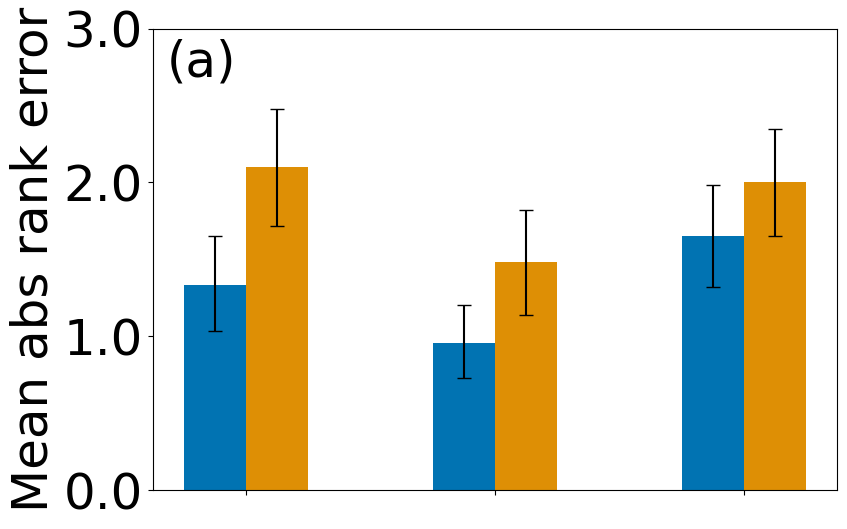

In [7]:
dataset_names = ["AUT", "MBC", "LSST"]

total_diff_model  = np.array([AUTpred, MBCpred, LSSTpred])
model_ci_low = np.array([AUTci_low, MBCci_low, LSSTci_low])
model_ci_high = np.array([AUTci_high, MBCci_high, LSSTci_high])

pure_null_mean         = np.array([AUTnull, MBCnull, LSSTnull])
pure_ci_low            = np.array([AUTnull_ci_low, MBCnull_ci_low, LSSTnull_ci_low])
pure_ci_high           = np.array([AUTnull_ci_high, MBCnull_ci_high, LSSTnull_ci_high])


model_err_lower = total_diff_model - model_ci_low
model_err_upper = model_ci_high - total_diff_model
model_yerr = np.vstack([model_err_lower, model_err_upper])  # shape (2, n)


# Compute asymmetric error bars for the null
null_err_lower = pure_null_mean - pure_ci_low
null_err_upper = pure_ci_high - pure_null_mean
null_yerr = np.vstack([null_err_lower, null_err_upper])  # shape (2, n)

x = np.arange(len(dataset_names))  # [0, 1, 2]
width = 0.25                       # bar width

fig, ax = plt.subplots(figsize=(8, 5))

# Bars for each metric
ax.bar(x - 0.5*width, total_diff_model,  width, yerr = model_yerr, capsize=5, label="Model")
#ax.bar(x,         total_guess_model, width, yerr = guess_yerr, capsize=5, label="Guess")
ax.bar(
    x + 0.5*width,
    pure_null_mean,
    width,
    yerr=null_yerr,
    capsize=5,
    label="Null",
)

ax.text(
    0.02, 0.98, "(a)",
    transform=ax.transAxes,   # axes fraction coords: (0,0)=bottom-left, (1,1)=top-right
    ha="left", va="top",
    fontsize=36,
)

# Formatting
ax.set_xticks(x)
#ax.set_xticklabels(dataset_names)
ax.set_xticklabels([])
ax.set_ylabel("Mean abs rank error", fontsize=36)
#ax.set_title("Rank prediction error by dataset")
#ax.legend(ncol=2, fontsize=16)
fig.tight_layout()
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels(["0.0", "1.0", "2.0", "3.0"])
plt.xticks(fontsize=24)  # X-axis tick font size
plt.yticks(fontsize=36)  # Y-axis tick font size
plt.ylim([0,3])
plt.savefig("/results/figure5(a).pdf", format='pdf', bbox_inches="tight")
plt.show()

## Time evaluation

In [8]:
#bootstrap rmse / pearson corr
def rmse_series(y_true, y_pred):
    diff = y_true - y_pred
    return np.sqrt(np.nanmean(np.square(diff)))

def pearsonr_safe(x, y):
    """Pearson r without SciPy; returns NaN if either series has zero variance or no data."""
    x = np.asarray(x); y = np.asarray(y)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    if x.size < 2:
        return np.nan
    sx = x.std(ddof=1); sy = y.std(ddof=1)
    if sx == 0 or sy == 0:
        return np.nan
    return np.corrcoef(x, y)[0, 1]

def bootstrap_rmse_over_dfs(
    df_list,
    truth_col,
    pred_col,
    B=2000,
    k=None,          # number of dataframes per bootstrap draw; default = len(df_list)
    seed=42
):
    """
    Cluster bootstrap over a list of dataframes.
    Each bootstrap replicate samples k dataframes (with replacement), concatenates them,
    and computes RMSE between truth_col and pred_col on the concatenated sample.
    """
    rng = np.random.default_rng(seed)
    m = len(df_list)
    if m == 0:
        return {
            "rmse": np.nan, "rho": np.nan,
            "rmse_mean": np.nan, "rmse_se": np.nan, "rmse_ci_low": np.nan, "rmse_ci_high": np.nan,
            "rho_mean": np.nan,  "rho_se": np.nan,  "rho_ci_low": np.nan,  "rho_ci_high": np.nan,
            "n_rows_point": 0, "k_used": 0
        }
    if k is None:
        k = m

    # Point estimate using one *non-bootstrap* sample of k dataframes (without replacement)
    # to match your “sample 10 then concat” workflow.
    k_point = min(k, m)
    point_idxs = rng.choice(m, size=k_point, replace=False)
    point_df = pd.concat([df_list[i] for i in point_idxs], axis=0, ignore_index=True)
    point_df = point_df[[truth_col, pred_col]].dropna()
    point_rmse = rmse_series(point_df[truth_col].to_numpy(), point_df[pred_col].to_numpy())
    point_rho  = pearsonr_safe(point_df[truth_col].to_numpy(), point_df[pred_col].to_numpy())

    # Bootstrap
    rmses = np.empty(B)
    rho_draws = np.empty(B)
    for b in range(B):
        idxs = rng.integers(0, m, size=k)   # sample dataframes with replacement
        boot_df = pd.concat([df_list[i] for i in idxs], axis=0, ignore_index=True)
        arr = boot_df[[truth_col, pred_col]].dropna().to_numpy()
        if len(arr) == 0:
            rmses[b] = np.nan
            rho_draws[b]  = np.nan
        else:
            rmses[b] = rmse_series(arr[:, 0], arr[:, 1])
            rho_draws[b]  = pearsonr_safe(arr[:, 0], arr[:, 1])

    # Remove potential NaNs (in case some draw produced no rows after dropna)
    rmses = rmses[~np.isnan(rmses)]
    if len(rmses) == 0:
        return {"rmse": point_rmse, "boot_mean": np.nan, "boot_se": np.nan,
                "ci_low": np.nan, "ci_high": np.nan, "n_rows_point": len(point_df), "k_used": k}

    ci_low, ci_high = np.percentile(rmses, [2.5, 97.5])
    rho_ci_low,  rho_ci_high  = np.percentile(rho_draws,  [2.5, 97.5])
    return {
        "rmse": point_rmse,
        "rho": point_rho,
        "rmse_mean": rmses.mean(),
        "rmse_se": rmses.std(ddof=1),
        "rmse_ci_low": ci_low,
        "rmse_ci_high": ci_high,
        "rho_mean": rho_draws.mean(),
        "rho_se": rho_draws.std(ddof=1),
        "rho_ci_low": rho_ci_low,
        "rho_ci_high": rho_ci_high,
        "n_rows_point": len(point_df),
        "k_used": k
    }


In [9]:
#LSST
cols = {
    "Model": "Model Time",
    "Guess": "Guess Time",
    "Random": "Random Time",
    "Pure Random": "Pure Random Time"
}

input_file = "/data/time_list_LSST.xlsx"

xls = pd.ExcelFile(input_file)
SpeakingTime_list = [
    pd.read_excel(input_file, sheet_name=sheet)
    for sheet in xls.sheet_names
]

SpeakingTime_list_tmp = SpeakingTime_list

results = {
    name: bootstrap_rmse_over_dfs(
        SpeakingTime_list_tmp,
        truth_col="Real Time",
        pred_col=pred_col,
        B=2000,
        k=10,
        seed=123
    )
    for name, pred_col in cols.items()
}

LSSTsummary = pd.DataFrame(results).T[
    [
        "rmse", "rmse_mean", "rmse_se", "rmse_ci_low", "rmse_ci_high",
        "rho",  "rho_mean",  "rho_se",  "rho_ci_low",  "rho_ci_high",
        "n_rows_point", "k_used"
    ]
]
LSSTsummary

,rmse,rmse_mean,rmse_se,rmse_ci_low,rmse_ci_high,rho,rho_mean,rho_se,rho_ci_low,rho_ci_high,n_rows_point,k_used
Model,0.083696,0.084980,0.005881,0.072189,0.094426,0.495529,0.425744,0.179199,0.119070,0.736969,56.0,10.0
Guess,0.084538,0.085947,0.006489,0.071654,0.097588,0.546346,0.478187,0.167827,0.202132,0.761003,56.0,10.0
Random,0.124593,0.119235,0.021620,0.085341,0.166091,0.047366,0.049500,0.105492,-0.142779,0.268256,56.0,10.0
Pure Random,0.095097,0.091785,0.012100,0.073320,0.118184,-0.015976,-0.035731,0.105636,-0.249189,0.161204,56.0,10.0


,rmse,rmse_mean,rmse_se,rmse_ci_low,rmse_ci_high,rho,rho_mean,rho_se,rho_ci_low,rho_ci_high,n_rows_point,k_used
Model,0.083696,0.084980,0.005881,0.072189,0.094426,0.495529,0.425744,0.179199,0.119070,0.736969,56.0,10.0
Guess,0.084538,0.085947,0.006489,0.071654,0.097588,0.546346,0.478187,0.167827,0.202132,0.761003,56.0,10.0
Random,0.124593,0.119235,0.021620,0.085341,0.166091,0.047366,0.049500,0.105492,-0.142779,0.268256,56.0,10.0
Pure Random,0.095097,0.091785,0.012100,0.073320,0.118184,-0.015976,-0.035731,0.105636,-0.249189,0.161204,56.0,10.0


In [11]:
#AUT
cols = {
    "Model": "Model Time",
    "Guess": "Guess Time",
    "Random": "Random Time",
    "Pure Random": "Pure Random Time"
}

input_file = "/data/time_list_AUT.xlsx"

xls = pd.ExcelFile(input_file)
SpeakingTime_list = [
    pd.read_excel(input_file, sheet_name=sheet)
    for sheet in xls.sheet_names
]

SpeakingTime_list_tmp = SpeakingTime_list

results = {
    name: bootstrap_rmse_over_dfs(
        SpeakingTime_list_tmp,
        truth_col="Real Time",
        pred_col=pred_col,
        B=2000,
        k=10,
        seed=123
    )
    for name, pred_col in cols.items()
}

AUTsummary = pd.DataFrame(results).T[
    [
        "rmse", "rmse_mean", "rmse_se", "rmse_ci_low", "rmse_ci_high",
        "rho",  "rho_mean",  "rho_se",  "rho_ci_low",  "rho_ci_high",
        "n_rows_point", "k_used"
    ]
]
AUTsummary

,rmse,rmse_mean,rmse_se,rmse_ci_low,rmse_ci_high,rho,rho_mean,rho_se,rho_ci_low,rho_ci_high,n_rows_point,k_used
Model,0.051888,0.051518,0.004911,0.042318,0.060883,0.760382,0.760561,0.057514,0.647233,0.867459,49.0,10.0
Guess,0.061544,0.060724,0.008998,0.046143,0.076684,0.660164,0.677028,0.035814,0.620778,0.751801,49.0,10.0
Random,0.118669,0.116653,0.021280,0.077059,0.157030,-0.147874,-0.136101,0.135879,-0.362108,0.174395,49.0,10.0
Pure Random,0.081481,0.080616,0.009651,0.063904,0.099155,0.002591,-0.000932,0.080953,-0.171770,0.148289,49.0,10.0


In [12]:
#MBC
cols = {
    "Model": "Model Time",
    "Guess": "Guess Time",
    "Random": "Random Time",
    "Pure Random": "Pure Random Time"
}

input_file = "/data/time_list_MBC.xlsx"

xls = pd.ExcelFile(input_file)
SpeakingTime_list = [
    pd.read_excel(input_file, sheet_name=sheet)
    for sheet in xls.sheet_names
]

SpeakingTime_list_tmp = SpeakingTime_list

results = {
    name: bootstrap_rmse_over_dfs(
        SpeakingTime_list_tmp,
        truth_col="Real Time",
        pred_col=pred_col,
        B=2000,
        k=10,
        seed=123
    )
    for name, pred_col in cols.items()
}

MBCsummary = pd.DataFrame(results).T[
    [
        "rmse", "rmse_mean", "rmse_se", "rmse_ci_low", "rmse_ci_high",
        "rho",  "rho_mean",  "rho_se",  "rho_ci_low",  "rho_ci_high",
        "n_rows_point", "k_used"
    ]
]
MBCsummary

,rmse,rmse_mean,rmse_se,rmse_ci_low,rmse_ci_high,rho,rho_mean,rho_se,rho_ci_low,rho_ci_high,n_rows_point,k_used
Model,0.069095,0.069043,0.008644,0.052473,0.085770,0.561722,0.572089,0.106404,0.349556,0.763581,44.0,10.0
Guess,0.065594,0.065408,0.005410,0.053945,0.074939,0.620873,0.636023,0.064295,0.512773,0.763284,44.0,10.0
Random,0.120329,0.120551,0.015010,0.093513,0.150506,0.070551,0.048416,0.230520,-0.460176,0.414477,44.0,10.0
Pure Random,0.089093,0.089281,0.006901,0.075885,0.103058,-0.111190,-0.105559,0.081532,-0.254099,0.059552,44.0,10.0


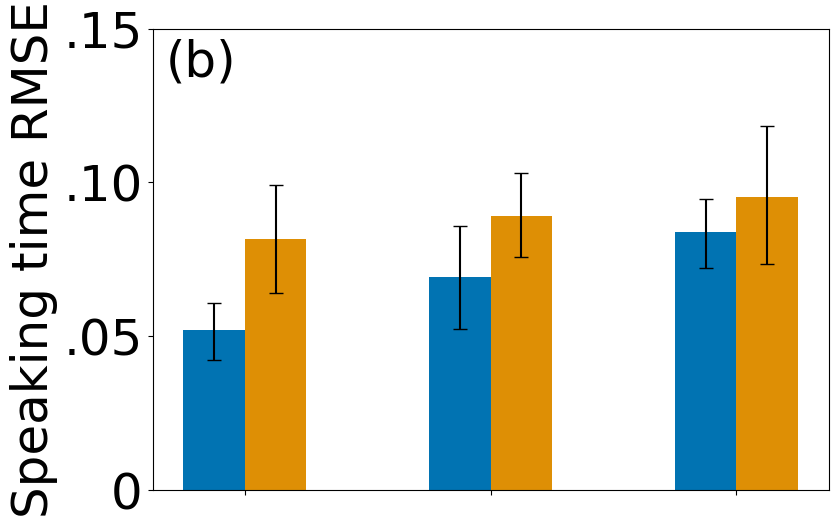

In [13]:
dataset_names = ["AUT", "MBC", "LSST"]

total_diff_model  = np.array([AUTsummary['rmse'].loc['Model'], MBCsummary['rmse'].loc['Model'], LSSTsummary['rmse'].loc['Model']])
model_ci_low = np.array([AUTsummary['rmse_ci_low'].loc['Model'], MBCsummary['rmse_ci_low'].loc['Model'], LSSTsummary['rmse_ci_low'].loc['Model']])
model_ci_high = np.array([AUTsummary['rmse_ci_high'].loc['Model'], MBCsummary['rmse_ci_high'].loc['Model'], LSSTsummary['rmse_ci_high'].loc['Model']])


pure_null_mean         = np.array([AUTsummary['rmse'].loc['Pure Random'], MBCsummary['rmse'].loc['Pure Random'], LSSTsummary['rmse'].loc['Pure Random']])
pure_ci_low            = np.array([AUTsummary['rmse_ci_low'].loc['Pure Random'], MBCsummary['rmse_ci_low'].loc['Pure Random'], LSSTsummary['rmse_ci_low'].loc['Pure Random']])
pure_ci_high           = np.array([AUTsummary['rmse_ci_high'].loc['Pure Random'], MBCsummary['rmse_ci_high'].loc['Pure Random'], LSSTsummary['rmse_ci_high'].loc['Pure Random']])


model_err_lower = total_diff_model - model_ci_low
model_err_upper = model_ci_high - total_diff_model
model_yerr = np.vstack([model_err_lower, model_err_upper])  # shape (2, n)

pure_err_lower = pure_null_mean - pure_ci_low
pure_err_upper = pure_ci_high - pure_null_mean
pure_null_yerr = np.vstack([pure_err_lower, pure_err_upper])  # shape (2, n)

x = np.arange(len(dataset_names))  # [0, 1, 2]
width = 0.25                       # bar width

fig, ax = plt.subplots(figsize=(8, 5))

# Bars for each metric
ax.bar(x - 0.5*width, total_diff_model,  width, yerr = model_yerr, capsize=5, label="Model")

ax.bar(
    x + 0.5*width,
    pure_null_mean,
    width,
    yerr=pure_null_yerr,
    capsize=5,
    label="Null",
)

ax.text(
    0.02, 0.98, "(b)",
    transform=ax.transAxes,   # axes fraction coords: (0,0)=bottom-left, (1,1)=top-right
    ha="left", va="top",
    fontsize=36,
)

# Formatting
ax.set_xticks(x)
#ax.set_xticklabels(dataset_names)
ax.set_xticklabels([])
ax.set_ylabel("Speaking time RMSE", fontsize=36)
#ax.set_title("Rank prediction error by dataset")
#ax.legend(ncol=2, fontsize=16)
fig.tight_layout()
ax.set_yticks([0, 0.05, 0.1, 0.15])
ax.set_yticklabels(["0", ".05", ".10", ".15"])
plt.xticks(fontsize=24)  # X-axis tick font size
plt.yticks(fontsize=36)  # Y-axis tick font size
plt.ylim([0,0.15])
plt.savefig("/results/figure5(b).pdf", format='pdf', bbox_inches="tight")
plt.show()

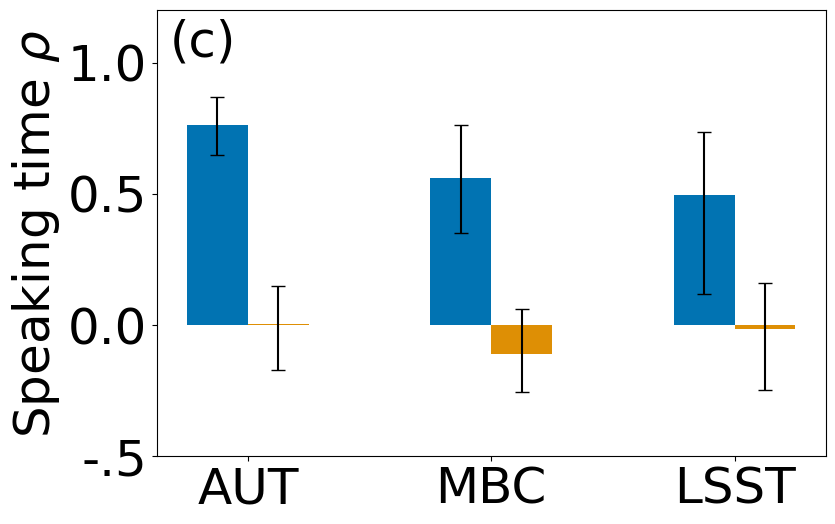

In [14]:
dataset_names = ["AUT", "MBC", "LSST"]

total_diff_model  = np.array([AUTsummary['rho'].loc['Model'], MBCsummary['rho'].loc['Model'], LSSTsummary['rho'].loc['Model']])
model_ci_low = np.array([AUTsummary['rho_ci_low'].loc['Model'], MBCsummary['rho_ci_low'].loc['Model'], LSSTsummary['rho_ci_low'].loc['Model']])
model_ci_high = np.array([AUTsummary['rho_ci_high'].loc['Model'], MBCsummary['rho_ci_high'].loc['Model'], LSSTsummary['rho_ci_high'].loc['Model']])


pure_null_mean         = np.array([AUTsummary['rho'].loc['Pure Random'], MBCsummary['rho'].loc['Pure Random'], LSSTsummary['rho'].loc['Pure Random']])
pure_ci_low            = np.array([AUTsummary['rho_ci_low'].loc['Pure Random'], MBCsummary['rho_ci_low'].loc['Pure Random'], LSSTsummary['rho_ci_low'].loc['Pure Random']])
pure_ci_high           = np.array([AUTsummary['rho_ci_high'].loc['Pure Random'], MBCsummary['rho_ci_high'].loc['Pure Random'], LSSTsummary['rho_ci_high'].loc['Pure Random']])


model_err_lower = total_diff_model - model_ci_low
model_err_upper = model_ci_high - total_diff_model
model_yerr = np.vstack([model_err_lower, model_err_upper])  # shape (2, n)

pure_err_lower = pure_null_mean - pure_ci_low
pure_err_upper = pure_ci_high - pure_null_mean
pure_null_yerr = np.vstack([pure_err_lower, pure_err_upper])  # shape (2, n)

x = np.arange(len(dataset_names))  # [0, 1, 2]
width = 0.25                       # bar width

fig, ax = plt.subplots(figsize=(8, 5))

# Bars for each metric
ax.bar(x - 0.5*width, total_diff_model,  width, yerr = model_yerr, capsize=5, label="Model")

ax.bar(
    x + 0.5*width,
    pure_null_mean,
    width,
    #yerr=pure_null_yerr,
    yerr=np.vstack([pure_err_lower, pure_err_upper]),
    capsize=5,
    label="Null",
)

ax.text(
    0.02, 0.98, "(c)",
    transform=ax.transAxes,   # axes fraction coords: (0,0)=bottom-left, (1,1)=top-right
    ha="left", va="top",
    fontsize=36,
)


# Formatting
ax.set_xticks(x)
ax.set_xticklabels(dataset_names)
ax.set_ylabel(r"Speaking time $\rho$", fontsize=36)
fig.tight_layout()
ax.set_yticks([-0.5, 0, 0.5, 1])
ax.set_yticklabels(["-.5", "0.0", "0.5", "1.0"])
plt.xticks(fontsize=36)  # X-axis tick font size
plt.yticks(fontsize=36)  # Y-axis tick font size
plt.ylim([-0.5,1.2])
plt.savefig("/results/figure5(c).pdf", format='pdf', bbox_inches="tight")
plt.show()

## Reciprocal time evaluation

In [15]:
def combine_turn(df, thres=0.4):
    df = df[df['confidence']>thres].reset_index(drop=True)
    df2 = pd.DataFrame({
    'duration': df['end'] - df['start'],
    'speaker_id': df['speaker_id']})
    # Step 2: Collapse consecutive identical IDs
    # Create a group identifier that increments when the ID changes
    group = (df2['speaker_id'] != df2['speaker_id'].shift()).cumsum()

    # Group by that identifier and sum durations while keeping the first ID
    result = df2.groupby(group).agg({'duration': 'sum', 'speaker_id': 'first'}).reset_index(drop=True)
    return result

In [16]:
def turn_switch(df, thres=0.4):
    cleaned_df = df
    cleaned_df['prev_speaker_id'] = df['speaker_id'].shift(1)
    transition_df = cleaned_df[cleaned_df['speaker_id']!=cleaned_df['prev_speaker_id']].reset_index(drop=True)
    transition_df = transition_df.dropna().reset_index(drop=True)
    transition_df['prev_speaker_id'] = transition_df['prev_speaker_id'].astype(int)
    return transition_df

In [17]:
def transition_matrix(df):
    first_column = 'speaker_id'
    second_column = 'prev_speaker_id'
    states = df[first_column].unique()
    states.sort()
    transition_matrix_turn = pd.DataFrame(0, index=states, columns=states, dtype=float)
    transition_matrix_time = pd.DataFrame(0, index=states, columns=states, dtype=float)
    for i in range(len(df)):
        current_state = df[first_column].iloc[i]
        next_state = df[second_column].iloc[i]
        transition_matrix_turn.loc[current_state, next_state] += 1
        transition_matrix_time.loc[current_state, next_state] += df.iloc[i]['duration']
    return transition_matrix_time, transition_matrix_turn

In [18]:
def simple_rmse(predictions, targets):
    return np.sqrt(np.sum((predictions-targets)**2))

In [19]:
def bootstrap_mean_ci(x, B=10000, alpha=0.05, rng=None):
    """
    Bootstrap 95% CI (by default) for the mean of samples x.
    Returns (mean, ci_low, ci_high).
    """
    x = np.asarray(x)
    n = len(x)
    if rng is None:
        rng = np.random.default_rng()
    
    boot_means = np.empty(B)
    for i in range(B):
        sample = rng.choice(x, size=n, replace=True)
        boot_means[i] = sample.mean()
    
    mean = x.mean()
    ci_low, ci_high = np.percentile(
        boot_means, [100 * alpha / 2, 100 * (1 - alpha / 2)]
    )
    return mean, ci_low, ci_high

In [20]:
#Pure random
def simulate_speaking_totals_with_pairs(
    n_intervals=200,
    n_speakers=10,
    mean=1.0,
    std=0.1,
    seed=42,
    clip_nonnegative=False,
):
    rng = np.random.default_rng(seed)

    lengths = rng.normal(loc=mean, scale=std, size=n_intervals)
    if clip_nonnegative:
        lengths = np.clip(lengths, 0.0, None)

    speaker_ids = rng.integers(low=0, high=n_speakers, size=n_intervals)

    totals = np.bincount(speaker_ids, weights=lengths, minlength=n_speakers).astype(float)

    pair_before_time = np.zeros((n_speakers, n_speakers), dtype=float)
    pair_next_time   = np.zeros((n_speakers, n_speakers), dtype=float)
    pair_pair_time   = np.zeros((n_speakers, n_speakers), dtype=float)
    pair_counts      = np.zeros((n_speakers, n_speakers), dtype=int)

    if n_intervals >= 2:
        a = speaker_ids[:-1]   # speaker at t
        b = speaker_ids[1:]    # speaker at t+1

        # credit the "before" speaker's time (length at t)
        np.add.at(pair_before_time, (a, b), lengths[:-1])

        # credit the "after" speaker's time (length at t+1)
        np.add.at(pair_next_time, (a, b), lengths[1:])

        # credit both consecutive intervals
        np.add.at(pair_pair_time, (a, b), lengths[:-1] + lengths[1:])

        # count transitions
        np.add.at(pair_counts, (a, b), 1)

    return totals, pair_before_time, pair_next_time, pair_pair_time, pair_counts, speaker_ids, lengths

In [21]:
def rmse_matrix(pred, target, *, mask=None, ignore_diag=False, nan_policy="omit"):
    """
    RMSE between two N-by-N matrices.
    - mask: boolean array same shape; True means include that entry
    - ignore_diag: exclude diagonal entries
    - nan_policy: "omit" (ignore NaNs) or "propagate"
    """
    pred = np.asarray(pred, dtype=float)
    target = np.asarray(target, dtype=float)

    err = pred - target

    m = np.ones(err.shape, dtype=bool) if mask is None else mask.astype(bool).copy()
    if ignore_diag:
        np.fill_diagonal(m, False)

    if nan_policy == "omit":
        m &= np.isfinite(err)
    elif nan_policy != "propagate":
        raise ValueError("nan_policy must be 'omit' or 'propagate'")

    # If nothing is selected, fail loudly
    denom = np.sum(m)
    if denom == 0:
        raise ValueError("No valid entries to compute RMSE (mask/NaNs removed everything).")

    return np.sqrt(np.mean((err[m]) ** 2))

def bootstrap_mean_prediction_rmse(
    model_list, real_data, *,
    n_boot=5000,
    sample_size=None,
    ci=0.95,
    random_state=None,
    mask=None,
    ignore_diag=False,
    nan_policy="omit",
):
    """
    model_list: list (length S=10) of N-by-N matrices
    real_data: N-by-N matrix
    n_boot: number of bootstrap replicates
    sample_size: how many sessions to sample each replicate (default = S)
    ci: confidence level (e.g. 0.95 for 95% CI)
    """
    rng = np.random.default_rng(random_state)

    preds = np.stack([np.asarray(M, dtype=float) for M in model_list], axis=0)  # (S,N,N)
    real = np.asarray(real_data, dtype=float)

    S = preds.shape[0]
    if sample_size is None:
        sample_size = S

    rmses = np.empty(n_boot, dtype=float)

    for b in range(n_boot):
        idx = rng.integers(0, S, size=sample_size)  # sample with replacement
        mean_pred = preds[idx].mean(axis=0)
        rmses[b] = rmse_matrix(mean_pred, real, mask=mask, ignore_diag=ignore_diag, nan_policy=nan_policy)

    mean_rmse = rmses.mean()

    alpha = 1.0 - ci
    lo = np.quantile(rmses, alpha / 2)
    hi = np.quantile(rmses, 1 - alpha / 2)

    return {
        "mean_rmse": mean_rmse,
        "ci_level": ci,
        "ci": (lo, hi),
        "rmse_samples": rmses,  # keep if you want histogram/diagnostics
    }

In [22]:
folder_path = "/data/intervals_raw_data_MBC3/"
intro_end_list = [414,545,355,351,330,693,294,1667,800,547]
session_index = [0,2,4,6,7,8,9,10,11,14]

file_list = [f for f in listdir(folder_path) if f.startswith("MBC3") and f.endswith(".csv")]
file_list.sort()
dfs = []

for i,file_name in enumerate(file_list):
    file_path = join(folder_path, file_name)
    df = pd.read_csv(file_path)
    df = df[df['start']>intro_end_list[i]]
    dfs.append(df)

In [23]:
name_dfs = [[6,8,1,9,5,4,2,7,0],
            [5,8,3,0,2,6,9,7],
           [7,13,9,0,5,4,6,8,1],
            [8,2,9,3,1,6,10,4],
           [6,11,7,10,0,4,5,1,8,3],
            [4,6,9,7,1,3,10,8,5],
           [0,1,7,9,4,5,2,8,10],
           [10,3,11,4,5,9,8,0,1],
           [7,8,6,11,5,4,9,10,3,1],
           [7,5,9,6,8,1,3,2,4]
           ]
            


trans_matrix_turn_list = []
trans_matrix_time_list = []


first_column = 'speaker_id'
second_column = 'prev_speaker_id'

for i in range(len(dfs)):
    tmp_combined_df = combine_turn(dfs[i])
    transition_df = turn_switch(tmp_combined_df)
    
    tmp_states = name_dfs[i]
    tmp_transition_matrix_turn = pd.DataFrame(0, index=tmp_states, columns=tmp_states, dtype=float)
    tmp_transition_matrix_time = pd.DataFrame(0, index=tmp_states, columns=tmp_states, dtype=float)
    
    for j in range(len(transition_df)):
        current_state = transition_df[first_column].iloc[j] #'order'
        next_state = transition_df[second_column].iloc[j] #'order'
        if current_state in tmp_states and next_state in tmp_states:
        
            tmp_transition_matrix_turn.loc[current_state, next_state] += 1 #in transition matrix, the state is 'name'
            tmp_transition_matrix_time.loc[current_state, next_state] += transition_df.iloc[j]['duration']
            
    
    trans_matrix_turn_list.append(tmp_transition_matrix_turn)
    trans_matrix_time_list.append(tmp_transition_matrix_time)

In [24]:
#real data
#Facilitator already removed
N = 8
result_array = np.zeros((N,N))
data_list = []
for i in range(len(trans_matrix_time_list)):
    tmp = trans_matrix_time_list[i].to_numpy()
    row_sums = np.sum(tmp, axis=1)
    sorted_indices = np.argsort(row_sums)[::-1]
    sorted_array = tmp[np.ix_(sorted_indices, sorted_indices)]
    data_list.append(sorted_array/np.sum(sorted_array))
    result_array += sorted_array[:N, :N]/np.sum(sorted_array[:N, :N])
result_array = result_array/len(trans_matrix_time_list)
result_array = result_array/np.sum(result_array)

In [25]:
#dynamical model
#prediction for each session and individual
session_index = [0,2,4,6,7,8,9,10,11,14]
model_list = []
model_array = np.zeros((N,N))

for j,i in enumerate(session_index):
    turn_df = pd.read_csv('/data/reciprocal_predtime_MBC3/'+str(i)+'.csv',header=None)
    tmp = turn_df.values
    row_sums = np.sum(tmp, axis=1)
    sorted_indices = np.argsort(row_sums)[::-1]
    sorted_array = tmp[np.ix_(sorted_indices, sorted_indices)]
    #sorted_array = np.sort(sorted_array, axis=1)[:, ::-1]
    model_list.append(sorted_array/sorted_array.sum())
    model_array += sorted_array[:N, :N]/np.sum(sorted_array[:N, :N])

model_array = model_array/len(session_index)
model_array = model_array/np.sum(model_array)
                                         

In [26]:
trail = 1
N = 8
pure_random_trail_list = []
for j in range(trail):
    random_array = np.zeros((N,N))
    random_list = []
    for i in range(len(dfs)):
        totals, before, after, both, counts, spk, lengths = simulate_speaking_totals_with_pairs(n_intervals=200,
            n_speakers=len(data_list[i]),
            mean=1.0,
            std=0.1,
            seed=i,
            clip_nonnegative=False,)
        for k in range(len(before)):
            before[k,k] = 0
        row_sums = np.sum(before, axis=1)
        sorted_indices = np.argsort(row_sums)[::-1]
        sorted_array = before[np.ix_(sorted_indices, sorted_indices)]
        random_list.append(sorted_array/np.sum(sorted_array))
        random_array += sorted_array[:N, :N]/np.sum(sorted_array[:N,:N])
    random_array = random_array/len(random_list)
    random_array = random_array/np.sum(random_array)
    pure_random_trail_list.append(random_array)

In [27]:
modified_random_list = []
modified_model_list = []
for i in range(len(random_list)):
    modified_random_list.append(random_list[i][:N,:N]/np.sum(random_list[i][:N,:N]))
    modified_model_list.append(model_list[i][:N,:N]/np.sum(model_list[i][:N,:N]))

In [28]:
MBCmodel_rmse = bootstrap_mean_prediction_rmse(
    modified_model_list,
    result_array,
    n_boot=2000,
    sample_size=10,        # “sample from 10 sessions” each replicate
    ci=0.95,
    random_state=0,
    ignore_diag=True,      # common for interaction matrices
)

MBCmodel_rmse["mean_rmse"], MBCmodel_rmse["ci"]

(0.010668451527034582, (0.009331624012046494, 0.012297536546738645))

In [29]:
MBCnull_rmse = bootstrap_mean_prediction_rmse(
    modified_random_list,
    result_array,
    n_boot=2000,
    sample_size=10,        # “sample from 10 sessions” each replicate
    ci=0.95,
    random_state=0,
    ignore_diag=True,      # common for interaction matrices
)
MBCnull_rmse["mean_rmse"], MBCnull_rmse["ci"]

(0.014218530174688208, (0.013425147351909344, 0.015258724376694842))

In [30]:
folder_path = "/data/intervals_raw_data_LSST2/"
intro_end_list = [1246,933,538,835,805,925,504,486,507,536,676]
session_index = [0,2,3,5,6,7,9,10,11,12,13]

file_list = [f for f in listdir(folder_path) if f.startswith("LSST2") and f.endswith(".csv")]
file_list.sort()
dfs = []

for i,file_name in enumerate(file_list):
    file_path = join(folder_path, file_name)
    df = pd.read_csv(file_path)
    df = df[df['start']>intro_end_list[i]]
    dfs.append(df)

In [31]:
name_dfs = [[2,3,6,8,7,0,4,5,9],
            [3,2,0,7,1,5,10,9,8],
           [3,11,0,6,9,1,8,7,4],
            [7,10,5,1,11,4,0,2,8,9],
           [1,3,8,9,5,0,2,7],
            [10,9,0,3,1,6,7,4,12,5,11],
            [4,8,2,1,5,6,3,11,7,10],
            [3,8,6,7,9,5,2,1],
            [6,7,2,4,3,5,8,9],
            [2,10,1,4,6,3,5,9,11,7],
            [6,None,4,8,3,5,None,0]
           ]
            


trans_matrix_turn_list = []
trans_matrix_time_list = []


first_column = 'speaker_id'
second_column = 'prev_speaker_id'

for i in range(len(dfs)):
    tmp_combined_df = combine_turn(dfs[i])
    transition_df = turn_switch(tmp_combined_df)
    
    tmp_states = name_dfs[i]
    tmp_transition_matrix_turn = pd.DataFrame(0, index=tmp_states, columns=tmp_states, dtype=float)
    tmp_transition_matrix_time = pd.DataFrame(0, index=tmp_states, columns=tmp_states, dtype=float)
    
    for j in range(len(transition_df)):
        current_state = transition_df[first_column].iloc[j] #'order'
        next_state = transition_df[second_column].iloc[j] #'order'
        if current_state in tmp_states and next_state in tmp_states:
        
            tmp_transition_matrix_turn.loc[current_state, next_state] += 1 #in transition matrix, the state is 'name'
            tmp_transition_matrix_time.loc[current_state, next_state] += transition_df.iloc[j]['duration']
            
    
    trans_matrix_turn_list.append(tmp_transition_matrix_turn)
    trans_matrix_time_list.append(tmp_transition_matrix_time)

In [32]:
#real data
#Facilitator already removed
N = 8
result_array = np.zeros((N,N))
data_list = []
for i in range(len(trans_matrix_time_list)):
    tmp = trans_matrix_time_list[i].to_numpy()
    row_sums = np.sum(tmp, axis=1)
    sorted_indices = np.argsort(row_sums)[::-1]
    sorted_array = tmp[np.ix_(sorted_indices, sorted_indices)]
    data_list.append(sorted_array/np.sum(sorted_array))
    result_array += sorted_array[:N, :N]/np.sum(sorted_array[:N, :N])
result_array = result_array/len(trans_matrix_time_list)
result_array = result_array/np.sum(result_array)

In [33]:
#dynamical model
#prediction for each session and individual
model_list = []
model_array = np.zeros((N,N))

for j,i in enumerate(session_index):
    turn_df = pd.read_csv('/data/reciprocal_predtime_LSST2/'+str(i)+'.csv',header=None)
    tmp = turn_df.values
    row_sums = np.sum(tmp, axis=1)
    sorted_indices = np.argsort(row_sums)[::-1]
    sorted_array = tmp[np.ix_(sorted_indices, sorted_indices)]
    #sorted_array = np.sort(sorted_array, axis=1)[:, ::-1]
    model_list.append(sorted_array/sorted_array.sum())
    model_array += sorted_array[:N, :N]/np.sum(sorted_array[:N, :N])

model_array = model_array/len(session_index)
model_array = model_array/np.sum(model_array)

In [34]:
trail = 1
N = 8
pure_random_trail_list = []
for j in range(trail):
    random_array = np.zeros((N,N))
    random_list = []
    for i in range(len(dfs)):
        totals, before, after, both, counts, spk, lengths = simulate_speaking_totals_with_pairs(n_intervals=200,
            n_speakers=len(data_list[i]),
            mean=1.0,
            std=0.1,
            seed=i,
            clip_nonnegative=False,)
        for k in range(len(before)):
            before[k,k] = 0
        row_sums = np.sum(before, axis=1)
        sorted_indices = np.argsort(row_sums)[::-1]
        sorted_array = before[np.ix_(sorted_indices, sorted_indices)]
        random_list.append(sorted_array/np.sum(sorted_array))
        random_array += sorted_array[:N, :N]/np.sum(sorted_array[:N,:N])
    random_array = random_array/len(random_list)
    random_array = random_array/np.sum(random_array)
    pure_random_trail_list.append(random_array)

In [35]:
modified_random_list = []
modified_model_list = []
for i in range(len(random_list)):
    modified_random_list.append(random_list[i][:N,:N]/np.sum(random_list[i][:N,:N]))
    modified_model_list.append(model_list[i][:N,:N]/np.sum(model_list[i][:N,:N]))

In [36]:
LSSTmodel_rmse = bootstrap_mean_prediction_rmse(
    modified_model_list,
    result_array,
    n_boot=2000,
    sample_size=10,        # “sample from 10 sessions” each replicate
    ci=0.95,
    random_state=0,
    ignore_diag=True,      # common for interaction matrices
)

LSSTmodel_rmse["mean_rmse"], LSSTmodel_rmse["ci"]

(0.009596099307179447, (0.009166283932159888, 0.01036235692536213))

In [37]:
LSSTnull_rmse = bootstrap_mean_prediction_rmse(
    modified_random_list,
    result_array,
    n_boot=2000,
    sample_size=10,        # “sample from 10 sessions” each replicate
    ci=0.95,
    random_state=0,
    ignore_diag=True,      # common for interaction matrices
)

LSSTnull_rmse["mean_rmse"], LSSTnull_rmse["ci"]

(0.013560500491500834, (0.01283610175686531, 0.014446320423635152))

In [38]:
#AUT
folder_path = "/data/intervals_raw_data_AUT2/"
session_index = [0,1,2,4,5,6,7,8,9,13]
intro_end_list = [617, 584, 805, 654, 542, 368, 478, 568, 469, 432]

file_list = [f for f in listdir(folder_path) if f.startswith("AUT2") and f.endswith(".csv")]
file_list.sort()
dfs = []

for i,file_name in enumerate(file_list):
    file_path = join(folder_path, file_name)
    df = pd.read_csv(file_path)
    df = df[df['start']>intro_end_list[i]]
    dfs.append(df)

In [39]:
name_dfs = [[2,4,7,1,6,0,10,5,8,11],
            [10,14,0,8,2,5,4,9,6,7,11],
            [10,8,5,4,3,9,2,12,1],
            [0,8,2,1,9,6,3,5],
            [3,7,5,4,8,0,10,1,9],
            [6,7,9,3,8,1,0,2,5],
            [8,10,2,4,5,3,6,0,7],
            [1,4,10,9,6,8,2,7,5],
            [1,7,4,6,5,9,3,2],
            [9,1,6,3,8,2,7,5,0]
           ]
            


trans_matrix_turn_list = []
trans_matrix_time_list = []


first_column = 'speaker_id'
second_column = 'prev_speaker_id'

for i in range(len(dfs)):
    tmp_combined_df = combine_turn(dfs[i])
    transition_df = turn_switch(tmp_combined_df)
    
    tmp_states = name_dfs[i]
    tmp_transition_matrix_turn = pd.DataFrame(0, index=tmp_states, columns=tmp_states, dtype=float)
    tmp_transition_matrix_time = pd.DataFrame(0, index=tmp_states, columns=tmp_states, dtype=float)
    
    for j in range(len(transition_df)):
        current_state = transition_df[first_column].iloc[j] #'order'
        next_state = transition_df[second_column].iloc[j] #'order'
        if current_state in tmp_states and next_state in tmp_states:
        
            tmp_transition_matrix_turn.loc[current_state, next_state] += 1 #in transition matrix, the state is 'name'
            tmp_transition_matrix_time.loc[current_state, next_state] += transition_df.iloc[j]['duration']
            
    
    trans_matrix_turn_list.append(tmp_transition_matrix_turn)
    trans_matrix_time_list.append(tmp_transition_matrix_time)

In [40]:
#real data
#Facilitator already removed
N = 8
result_array = np.zeros((N,N))
data_list = []
for i in range(len(trans_matrix_time_list)):
    tmp = trans_matrix_time_list[i].to_numpy()
    row_sums = np.sum(tmp, axis=1)
    sorted_indices = np.argsort(row_sums)[::-1]
    sorted_array = tmp[np.ix_(sorted_indices, sorted_indices)]
    data_list.append(sorted_array/np.sum(sorted_array))
    result_array += sorted_array[:N, :N]/np.sum(sorted_array[:N, :N])
result_array = result_array/len(trans_matrix_time_list)
result_array = result_array/np.sum(result_array)

In [41]:
#dynamical model
#prediction for each session and individual
model_list = []
model_array = np.zeros((N,N))

for j,i in enumerate(session_index):
    turn_df = pd.read_csv('/data/reciprocal_predtime_AUT2/'+str(j)+'.csv',header=None)
    tmp = turn_df.values
    row_sums = np.sum(tmp, axis=1)
    sorted_indices = np.argsort(row_sums)[::-1]
    sorted_array = tmp[np.ix_(sorted_indices, sorted_indices)]
    #sorted_array = np.sort(sorted_array, axis=1)[:, ::-1]
    model_list.append(sorted_array/sorted_array.sum())
    model_array += sorted_array[:N, :N]/np.sum(sorted_array[:N, :N])

model_array = model_array/len(session_index)
model_array = model_array/np.sum(model_array)

In [42]:
trail = 1
N = 8
pure_random_trail_list = []
for j in range(trail):
    random_array = np.zeros((N,N))
    random_list = []
    for i in range(len(dfs)):
        totals, before, after, both, counts, spk, lengths = simulate_speaking_totals_with_pairs(n_intervals=200,
            n_speakers=len(data_list[i]),
            mean=1.0,
            std=0.1,
            seed=i,
            clip_nonnegative=False,)
        for k in range(len(before)):
            before[k,k] = 0
        row_sums = np.sum(before, axis=1)
        sorted_indices = np.argsort(row_sums)[::-1]
        sorted_array = before[np.ix_(sorted_indices, sorted_indices)]
        random_list.append(sorted_array/np.sum(sorted_array))
        random_array += sorted_array[:N, :N]
    random_array = random_array/len(random_list)
    random_array = random_array/np.sum(random_array)
    pure_random_trail_list.append(random_array)

In [43]:
modified_random_list = []
modified_model_list = []
for i in range(len(random_list)):
    modified_random_list.append(random_list[i][:N,:N]/np.sum(random_list[i][:N,:N]))
    modified_model_list.append(model_list[i][:N,:N]/np.sum(model_list[i][:N,:N]))

In [44]:
AUTmodel_rmse = bootstrap_mean_prediction_rmse(
    modified_model_list,
    result_array,
    n_boot=2000,
    sample_size=10,        # “sample from 10 sessions” each replicate
    ci=0.95,
    random_state=0,
    ignore_diag=True,      # common for interaction matrices
)

AUTmodel_rmse["mean_rmse"], AUTmodel_rmse["ci"]

(0.012634268518190873, (0.012024071824013802, 0.013363891711060179))

In [45]:
AUTnull_rmse = bootstrap_mean_prediction_rmse(
    modified_random_list,
    result_array,
    n_boot=2000,
    sample_size=10,        # “sample from 10 sessions” each replicate
    ci=0.95,
    random_state=0,
    ignore_diag=True,      # common for interaction matrices
)

AUTnull_rmse["mean_rmse"], AUTnull_rmse["ci"]

(0.01710683218857033, (0.016400517208519767, 0.017982010467644822))

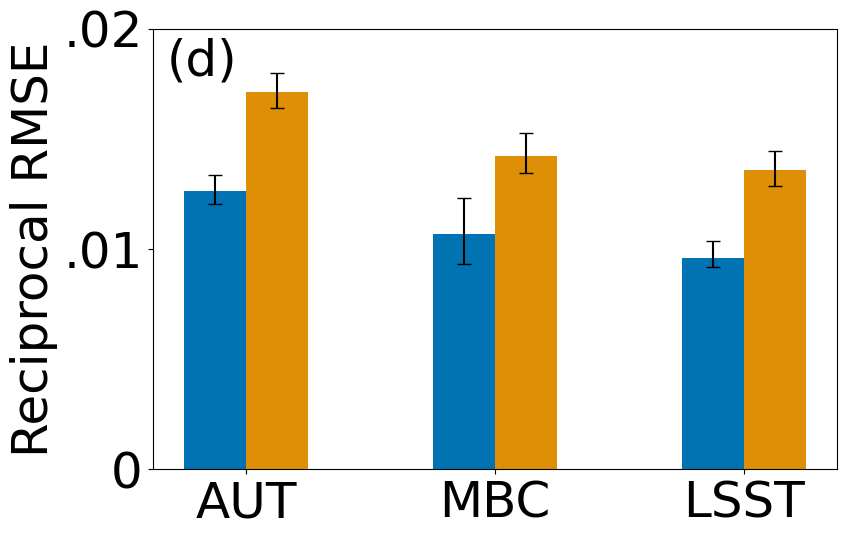

In [46]:
#Using data averaged over session

dataset_names = ["AUT", "MBC", "LSST"]


total_diff_model  = np.array([AUTmodel_rmse["mean_rmse"], MBCmodel_rmse["mean_rmse"], LSSTmodel_rmse["mean_rmse"]])
model_ci_low = np.array([AUTmodel_rmse["ci"][0], MBCmodel_rmse["ci"][0], LSSTmodel_rmse["ci"][0]])
model_ci_high = np.array([AUTmodel_rmse["ci"][1], MBCmodel_rmse["ci"][1], LSSTmodel_rmse["ci"][1]])


pure_null_mean         = np.array([AUTnull_rmse["mean_rmse"], MBCnull_rmse["mean_rmse"], LSSTnull_rmse["mean_rmse"]])
pure_ci_low            = np.array([AUTnull_rmse["ci"][0], MBCnull_rmse["ci"][0], LSSTnull_rmse["ci"][0]])
pure_ci_high           = np.array([AUTnull_rmse["ci"][1], MBCnull_rmse["ci"][1], LSSTnull_rmse["ci"][1]])


model_err_lower = total_diff_model - model_ci_low
model_err_upper = model_ci_high - total_diff_model
model_yerr = np.vstack([model_err_lower, model_err_upper])  # shape (2, n)


pure_err_lower = pure_null_mean - pure_ci_low
pure_err_upper = pure_ci_high - pure_null_mean
pure_yerr = np.vstack([pure_err_lower, pure_err_upper])  # shape (2, n)

x = np.arange(len(dataset_names))  # [0, 1, 2]
width = 0.25                       # bar width

fig, ax = plt.subplots(figsize=(8, 5))

# Bars for each metric
ax.bar(x - 0.5*width, total_diff_model,  width, yerr = model_yerr, capsize=5, label="Model")
#ax.bar(x,         total_guess_model, width, yerr = guess_yerr, capsize=5, label="Guess")
#ax.bar(x,         null_mean, width, yerr = null_yerr, capsize=5, label="Null")
ax.bar(
    x + 0.5*width,
    pure_null_mean,
    width,
    yerr=pure_yerr,
    capsize=5,
    label="Null",
)

ax.text(
    0.02, 0.98, "(d)",
    transform=ax.transAxes,   # axes fraction coords: (0,0)=bottom-left, (1,1)=top-right
    ha="left", va="top",
    fontsize=36,
)

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(dataset_names)
ax.set_yticks([0, 0.01, 0.02])
ax.set_yticklabels(["0", ".01", ".02"])
ax.set_ylabel("Reciprocal RMSE", fontsize=36)
#ax.set_title("Rank prediction error by dataset")
#ax.legend(ncol=2,fontsize=16)
fig.tight_layout()
plt.xticks(fontsize=36)  # X-axis tick font size
plt.yticks(fontsize=36)  # Y-axis tick font size
plt.ylim([0,0.02])
plt.savefig("/results/figure5(d).pdf", format='pdf', bbox_inches="tight")
plt.show()

## Limiting behavior of the model

In [47]:
input_file = "/data/limiting_behavior.xlsx"

xls = pd.ExcelFile(input_file)
gs2 = [
    pd.read_excel(input_file, sheet_name=sheet)
    for sheet in xls.sheet_names
]

In [48]:
SpeakingTime_list_tmp = gs2

In [49]:
# 40% missing data
cols = {
    "Model": "model_time",
    "Guess": "prior_time",
}

results = {
    name: bootstrap_rmse_over_dfs(
        SpeakingTime_list_tmp,
        truth_col="mess_time40",
        pred_col=pred_col,
        B=2000,
        k=10,
        seed=123
    )
    for name, pred_col in cols.items()
}

summary40 = pd.DataFrame(results).T[
    [
        "rmse", "rmse_mean", "rmse_se", "rmse_ci_low", "rmse_ci_high",
        "rho",  "rho_mean",  "rho_se",  "rho_ci_low",  "rho_ci_high",
        "n_rows_point", "k_used"
    ]
]
summary40

,rmse,rmse_mean,rmse_se,rmse_ci_low,rmse_ci_high,rho,rho_mean,rho_se,rho_ci_low,rho_ci_high,n_rows_point,k_used
Model,0.098663,0.096103,0.013722,0.068241,0.120456,0.313476,0.304632,0.128810,0.079327,0.577573,104.0,10.0
Guess,0.096588,0.093867,0.012901,0.067778,0.116328,0.309817,0.300475,0.124579,0.081530,0.563200,104.0,10.0


In [50]:
# 20% missing data
cols = {
    "Model": "model_time",
    "Guess": "prior_time",
}

results = {
    name: bootstrap_rmse_over_dfs(
        SpeakingTime_list_tmp,
        truth_col="mess_time20",
        pred_col=pred_col,
        B=2000,
        k=10,
        seed=123
    )
    for name, pred_col in cols.items()
}

summary20 = pd.DataFrame(results).T[
    [
        "rmse", "rmse_mean", "rmse_se", "rmse_ci_low", "rmse_ci_high",
        "rho",  "rho_mean",  "rho_se",  "rho_ci_low",  "rho_ci_high",
        "n_rows_point", "k_used"
    ]
]
summary20

,rmse,rmse_mean,rmse_se,rmse_ci_low,rmse_ci_high,rho,rho_mean,rho_se,rho_ci_low,rho_ci_high,n_rows_point,k_used
Model,0.077945,0.065121,0.017218,0.029210,0.096161,0.535008,0.668690,0.135470,0.409495,0.924906,104.0,10.0
Guess,0.074819,0.064335,0.014691,0.033581,0.091032,0.547315,0.666595,0.124183,0.433340,0.910519,104.0,10.0


In [51]:
# 10% missing data
cols = {
    "Model": "model_time",
    "Guess": "prior_time",
}

results = {
    name: bootstrap_rmse_over_dfs(
        SpeakingTime_list_tmp,
        truth_col="mess_time10",
        pred_col=pred_col,
        B=2000,
        k=10,
        seed=123
    )
    for name, pred_col in cols.items()
}

summary10 = pd.DataFrame(results).T[
    [
        "rmse", "rmse_mean", "rmse_se", "rmse_ci_low", "rmse_ci_high",
        "rho",  "rho_mean",  "rho_se",  "rho_ci_low",  "rho_ci_high",
        "n_rows_point", "k_used"
    ]
]
summary10

,rmse,rmse_mean,rmse_se,rmse_ci_low,rmse_ci_high,rho,rho_mean,rho_se,rho_ci_low,rho_ci_high,n_rows_point,k_used
Model,0.012039,0.011664,0.000858,0.010057,0.013388,0.990712,0.989871,0.003215,0.982214,0.994656,104.0,10.0
Guess,0.024534,0.021782,0.003205,0.015384,0.027984,0.950868,0.957569,0.012874,0.927776,0.978684,104.0,10.0


In [52]:
# 0% missing data
cols = {
    "Model": "model_time",
    "Guess": "prior_time",
}


results = {
    name: bootstrap_rmse_over_dfs(
        SpeakingTime_list_tmp,
        truth_col="real_time",
        pred_col=pred_col,
        B=2000,
        k=10,
        seed=123
    )
    for name, pred_col in cols.items()
}

summary0 = pd.DataFrame(results).T[
    [
        "rmse", "rmse_mean", "rmse_se", "rmse_ci_low", "rmse_ci_high",
        "rho",  "rho_mean",  "rho_se",  "rho_ci_low",  "rho_ci_high",
        "n_rows_point", "k_used"
    ]
]
summary0

,rmse,rmse_mean,rmse_se,rmse_ci_low,rmse_ci_high,rho,rho_mean,rho_se,rho_ci_low,rho_ci_high,n_rows_point,k_used
Model,0.003186,0.002693,0.000601,0.001588,0.003862,0.999266,0.999367,0.000313,0.998605,0.999800,104.0,10.0
Guess,0.024214,0.021718,0.003000,0.015604,0.027462,0.955958,0.963460,0.011998,0.938000,0.984641,104.0,10.0


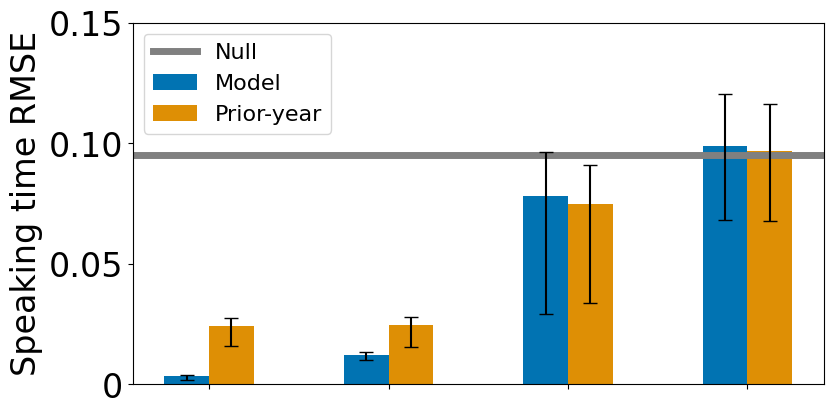

In [53]:
dataset_names = ["0%", '10%' ,"20%", "40%"]

total_diff_model  = np.array([summary0['rmse'].loc['Model'], summary10['rmse'].loc['Model'], summary20['rmse'].loc['Model'], summary40['rmse'].loc['Model']])
model_ci_low = np.array([summary0['rmse_ci_low'].loc['Model'], summary10['rmse_ci_low'].loc['Model'], summary20['rmse_ci_low'].loc['Model'], summary40['rmse_ci_low'].loc['Model']])
model_ci_high = np.array([summary0['rmse_ci_high'].loc['Model'], summary10['rmse_ci_high'].loc['Model'], summary20['rmse_ci_high'].loc['Model'], summary40['rmse_ci_high'].loc['Model']])

total_guess_model = np.array([summary0['rmse'].loc['Guess'], summary10['rmse'].loc['Guess'], summary20['rmse'].loc['Guess'], summary40['rmse'].loc['Guess']])
guess_ci_low = np.array([summary0['rmse_ci_low'].loc['Guess'], summary10['rmse_ci_low'].loc['Guess'], summary20['rmse_ci_low'].loc['Guess'], summary40['rmse_ci_low'].loc['Guess']])
guess_ci_high = np.array([summary0['rmse_ci_high'].loc['Guess'],summary10['rmse_ci_high'].loc['Guess'], summary20['rmse_ci_high'].loc['Guess'], summary40['rmse_ci_high'].loc['Guess']])


model_err_lower = total_diff_model - model_ci_low
model_err_upper = model_ci_high - total_diff_model
model_yerr = np.vstack([model_err_lower, model_err_upper])  # shape (2, n)

guess_err_lower = total_guess_model - guess_ci_low
guess_err_upper = guess_ci_high - total_guess_model
guess_yerr = np.vstack([guess_err_lower, guess_err_upper])  # shape (2, n)

x = np.arange(len(dataset_names))  # [0, 1, 2]
width = 0.25                       # bar width

fig, ax = plt.subplots(figsize=(8, 4))

#ax.axhspan(0.0718, 0.1230, color="grey", alpha=0.2, zorder=0)  # zorder=0 keeps it behind bars
#ax.axhline(0.0984, color="grey", linewidth=5, zorder=1)     # optional: reference line at y=1

# Bars for each metric
ax.bar(x - 0.5*width, total_diff_model,  width, yerr = model_yerr, capsize=5, label="Model")
ax.bar(x + 0.5*width, total_guess_model, width, yerr = guess_yerr, capsize=5, label="Prior-year")
ax.axhline(LSSTsummary['rmse'].loc['Pure Random'], color="grey", linewidth=5, zorder=1, label='Null')     # optional: reference line at y=1

# Formatting
ax.set_xticks(x)
ax.set_xticklabels([])
ax.set_ylabel("Speaking time RMSE", fontsize=24)
#ax.set_xlabel("Error in loquacity", fontsize=24)
#ax.set_title("Rank prediction error by dataset")
ax.legend(fontsize=16, loc='upper left')
fig.tight_layout()
ax.set_yticks([0, 0.05, 0.1, 0.15])
ax.set_yticklabels(["0", "0.05" , "0.10", "0.15"])
plt.xticks(fontsize=24)  # X-axis tick font size
plt.yticks(fontsize=24)  # Y-axis tick font size
plt.ylim([0,0.15])
plt.savefig("/results/figure6(a).pdf", format='pdf', bbox_inches="tight")
plt.show()

In [54]:
N = 10
real_list = []
real_array = np.zeros((N,N))

for i in range(15):
    turn_df = pd.read_csv('/data/identifibilitynomess_time_switch/'+str(i)+'.csv',header=None)
    tmp = turn_df.values
    row_sums = np.sum(tmp, axis=1)
    sorted_indices = np.argsort(row_sums)[::-1]
    sorted_array = tmp[np.ix_(sorted_indices, sorted_indices)]
    #sorted_array = np.sort(sorted_array, axis=1)[:, ::-1]
    real_list.append(sorted_array/sorted_array.sum())
    real_array += sorted_array[:N, :N]/np.sum(sorted_array[:N, :N])

real_array = real_array/15
real_array = real_array/np.sum(real_array)

In [55]:
N = 10
model_list = []
model_array = np.zeros((N,N))

for i in range(15):
    turn_df = pd.read_csv('/data/identifibility_time_switch_generate/'+str(i)+'.csv',header=None)
    tmp = turn_df.values
    row_sums = np.sum(tmp, axis=1)
    sorted_indices = np.argsort(row_sums)[::-1]
    sorted_array = tmp[np.ix_(sorted_indices, sorted_indices)]
    #sorted_array = np.sort(sorted_array, axis=1)[:, ::-1]
    model_list.append(sorted_array/sorted_array.sum())
    model_array += sorted_array[:N, :N]/np.sum(sorted_array[:N, :N])

model_array = model_array/15
model_array = model_array/np.sum(model_array)

In [56]:
N = 10
prior_list = []
prior_array = np.zeros((N,N))

for i in range(15):
    total_time = gs2[i]['prior_time'].to_numpy()
    tmp = np.outer(total_time, total_time)
    for j in range(len(tmp)):
        tmp[j,j] = 0
    row_sums = np.sum(tmp, axis=1)
    sorted_indices = np.argsort(row_sums)[::-1]
    sorted_array = tmp[np.ix_(sorted_indices, sorted_indices)]
    #sorted_array = np.sort(sorted_array, axis=1)[:, ::-1]
    prior_list.append(sorted_array/sorted_array.sum())
    prior_array += sorted_array[:N, :N]/np.sum(sorted_array[:N, :N])

prior_array = prior_array/15
prior_array = prior_array/np.sum(prior_array)

In [57]:
def simple_rmse(predictions, targets):
    return np.sqrt(np.sum((predictions-targets)**2))

In [58]:
N = 10
mess10_list = []
mess10_array = np.zeros((N,N))

for i in range(15):
    turn_df = pd.read_csv('/data/identifibilitymess10_time_switch/'+str(i)+'.csv',header=None)
    tmp = turn_df.values
    row_sums = np.sum(tmp, axis=1)
    sorted_indices = np.argsort(row_sums)[::-1]
    sorted_array = tmp[np.ix_(sorted_indices, sorted_indices)]
    #sorted_array = np.sort(sorted_array, axis=1)[:, ::-1]
    mess10_list.append(sorted_array/sorted_array.sum())
    mess10_array += sorted_array[:N, :N]/np.sum(sorted_array[:N, :N])

mess10_array = mess10_array/15
mess10_array = mess10_array/np.sum(mess10_array)

In [59]:
N = 10
mess20_list = []
mess20_array = np.zeros((N,N))

for i in range(15):
    turn_df = pd.read_csv('/data/identifibilitymess20_time_switch/'+str(i)+'.csv',header=None)
    tmp = turn_df.values
    row_sums = np.sum(tmp, axis=1)
    sorted_indices = np.argsort(row_sums)[::-1]
    sorted_array = tmp[np.ix_(sorted_indices, sorted_indices)]
    #sorted_array = np.sort(sorted_array, axis=1)[:, ::-1]
    mess20_list.append(sorted_array/sorted_array.sum())
    mess20_array += sorted_array[:N, :N]/np.sum(sorted_array[:N, :N])

mess20_array = mess20_array/15
mess20_array = mess20_array/np.sum(mess20_array)

In [60]:
N = 10
mess40_list = []
mess40_array = np.zeros((N,N))

for i in range(15):
    turn_df = pd.read_csv('/data/identifibilitymess40_time_switch/'+str(i)+'.csv',header=None)
    tmp = turn_df.values
    row_sums = np.sum(tmp, axis=1)
    sorted_indices = np.argsort(row_sums)[::-1]
    sorted_array = tmp[np.ix_(sorted_indices, sorted_indices)]
    #sorted_array = np.sort(sorted_array, axis=1)[:, ::-1]
    mess40_list.append(sorted_array/sorted_array.sum())
    mess40_array += sorted_array[:N, :N]/np.sum(sorted_array[:N, :N])

mess40_array = mess40_array/15
mess40_array = mess40_array/np.sum(mess40_array)

In [61]:
## Calculate difference 
rmse_mess10 = np.zeros((15,))
rmse_mess20 = np.zeros((15,))
rmse_mess40 = np.zeros((15,))
for i in range(15):
    rmse_mess10[i] = simple_rmse(mess10_list[i].reshape(len(mess10_list[i])**2,), model_list[i].reshape(len(mess10_list[i])**2,))
    rmse_mess20[i] = simple_rmse(mess20_list[i].reshape(len(mess10_list[i])**2,), model_list[i].reshape(len(mess10_list[i])**2,))
    rmse_mess40[i] = simple_rmse(mess40_list[i].reshape(len(mess10_list[i])**2,), model_list[i].reshape(len(mess10_list[i])**2,))
    

In [62]:
## Calculate difference 
rmse_prior10 = np.zeros((15,))
rmse_prior20 = np.zeros((15,))
rmse_prior40 = np.zeros((15,))
for i in range(15):
    rmse_prior10[i] = simple_rmse(mess10_list[i].reshape(len(mess10_list[i])**2,), prior_list[i].reshape(len(mess10_list[i])**2,))
    rmse_prior20[i] = simple_rmse(mess20_list[i].reshape(len(mess10_list[i])**2,), prior_list[i].reshape(len(mess10_list[i])**2,))
    rmse_prior40[i] = simple_rmse(mess40_list[i].reshape(len(mess10_list[i])**2,), prior_list[i].reshape(len(mess10_list[i])**2,))
    

In [63]:
## Calculate difference 
rmse_model = np.zeros((15,))
rmse_prior = np.zeros((15,))
for i in range(15):
    rmse_model[i] = simple_rmse(real_list[i].reshape(len(model_list[i])**2,), model_list[i].reshape(len(model_list[i])**2,))
    rmse_prior[i] = simple_rmse(real_list[i].reshape(len(prior_list[i])**2,), prior_list[i].reshape(len(prior_list[i])**2,))

In [64]:
def bootstrap_mean_ci(x, B=10000, alpha=0.05, rng=None):
    """
    Bootstrap 95% CI (by default) for the mean of samples x.
    Returns (mean, ci_low, ci_high).
    """
    x = np.asarray(x)
    n = len(x)
    if rng is None:
        rng = np.random.default_rng()
    
    boot_means = np.empty(B)
    for i in range(B):
        sample = rng.choice(x, size=n, replace=True)
        boot_means[i] = sample.mean()
    
    mean = x.mean()
    ci_low, ci_high = np.percentile(
        boot_means, [100 * alpha / 2, 100 * (1 - alpha / 2)]
    )
    return mean, ci_low, ci_high

In [65]:
mean_0, ci_low_0, ci_high_0 = bootstrap_mean_ci(rmse_model)
mean_10, ci_low_10, ci_high_10 = bootstrap_mean_ci(rmse_mess10)
mean_20, ci_low_20, ci_high_20 = bootstrap_mean_ci(rmse_mess20)
mean_40, ci_low_40, ci_high_40 = bootstrap_mean_ci(rmse_mess40)

prior_mean_0, prior_ci_low_0, prior_ci_high_0 = bootstrap_mean_ci(rmse_prior)
prior_mean_10, prior_ci_low_10, prior_ci_high_10 = bootstrap_mean_ci(rmse_prior10)
prior_mean_20, prior_ci_low_20, prior_ci_high_20 = bootstrap_mean_ci(rmse_prior20)
prior_mean_40, prior_ci_low_40, prior_ci_high_40 = bootstrap_mean_ci(rmse_prior40)

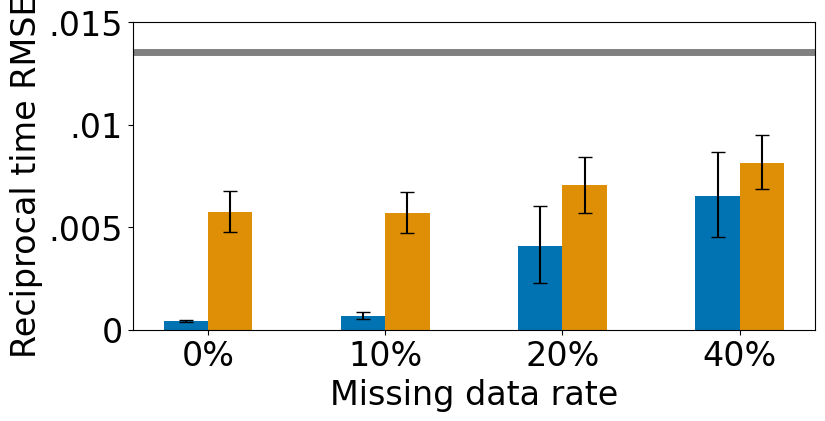

In [66]:
sns.set_palette("colorblind")
dataset_names = ["0%", '10%' ,"20%", "40%"]
M = 8

total_diff_model  = np.array([mean_0, mean_10, mean_20, mean_40])/M
model_ci_low = np.array([ci_low_0, ci_low_10, ci_low_20, ci_low_40])/M
model_ci_high = np.array([ci_high_0, ci_high_10, ci_high_20, ci_high_40])/M
total_guess_model = np.array([prior_mean_0, prior_mean_10, prior_mean_20, prior_mean_40])/M
guess_ci_low = np.array([prior_ci_low_0, prior_ci_low_10, prior_ci_low_20, prior_ci_low_40])/M
guess_ci_high = np.array([prior_ci_high_0, prior_ci_high_10, prior_ci_high_20, prior_ci_high_40])/M


model_err_lower = total_diff_model - model_ci_low
model_err_upper = model_ci_high - total_diff_model
model_yerr = np.vstack([model_err_lower, model_err_upper])  # shape (2, n)

guess_err_lower = total_guess_model - guess_ci_low
guess_err_upper = guess_ci_high - total_guess_model
guess_yerr = np.vstack([guess_err_lower, guess_err_upper])  # shape (2, n)

x = np.arange(len(dataset_names))  # [0, 1, 2]
width = 0.25                       # bar width

fig, ax = plt.subplots(figsize=(8, 4))

#ax.axhspan(0.01283, 0.01444, color="grey", alpha=0.2, zorder=0)  # zorder=0 keeps it behind bars

# Bars for each metric
ax.bar(x - 0.5*width, total_diff_model,  width, yerr = model_yerr, capsize=5, label="Model")
ax.bar(x + 0.5*width, total_guess_model, width, yerr = guess_yerr, capsize=5, label="Prior-year")
ax.axhline(0.01356, color="grey", linewidth=5, zorder=1, label="Null")     # optional: reference line at y=1

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(dataset_names)
ax.set_ylabel("Reciprocal time RMSE", fontsize=24)
ax.set_xlabel("Missing data rate", fontsize=24)
#ax.set_title("Rank prediction error by dataset")
#ax.legend(fontsize=16)
fig.tight_layout()
ax.set_yticks([0, .005, .01, .015])
ax.set_yticklabels(["0", ".005" , ".01", ".015"])
plt.xticks(fontsize=24)  # X-axis tick font size
plt.yticks(fontsize=24)  # Y-axis tick font size
plt.ylim([0,0.015])
plt.savefig("/results/figure6(b).pdf", format='pdf', bbox_inches="tight")
plt.show()